# Customer Segmentation using Unsupervised Learning

### What was learned & implemented in this notebook:
1. **Feature Extraction & Engineering**:
   - Computed Customer Tenure Days, Total Spending, and Total Children from raw date, income, purchase channel, and household size data.
2. **K-Means Clustering**:
   - Implemented Elbow Method and Silhouette Analysis to determine the optimal number of clusters (4 clusters).
   - Trained K-Means and visualized customer profiles for each segment.
3. **Hierarchical Agglomerative Clustering**:
   - Trained `AgglomerativeClustering` (linkage='ward', 4 clusters).
   - Plotted 3D projection plots showing cluster boundaries across income, spending, and age dimensions.
4. **Cluster Interpretation**:
   - Analyzed customer profiles (e.g. high-spending older customers, bargain hunters, low-spending families) to assist in targeted marketing campaigns.

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("smartcart_customers.csv")


In [6]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [7]:
df.shape

(2240, 22)

In [8]:
df.info

<bound method DataFrame.info of          ID  Year_Birth   Education Marital_Status   Income  Kidhome  \
0      5524        1957  Graduation         Single  58138.0        0   
1      2174        1954  Graduation         Single  46344.0        1   
2      4141        1965  Graduation       Together  71613.0        0   
3      6182        1984  Graduation       Together  26646.0        1   
4      5324        1981         PhD        Married  58293.0        1   
...     ...         ...         ...            ...      ...      ...   
2235  10870        1967  Graduation        Married  61223.0        0   
2236   4001        1946         PhD       Together  64014.0        2   
2237   7270        1981  Graduation       Divorced  56981.0        0   
2238   8235        1956      Master       Together  69245.0        0   
2239   9405        1954         PhD        Married  52869.0        1   

      Teenhome Dt_Customer  Recency  MntWines  ...  MntFishProducts  \
0            0  04-09-2012      

In [9]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [10]:
df["Income"]= df["Income"].fillna(df["Income"].median())

In [11]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

# FEAture Eng

In [12]:
#age
df["Age"]= 2026 - df["Year_Birth"]

In [13]:
#Customer joining date
df["Dt_Customer"]= pd.to_datetime(df["Dt_Customer"],dayfirst = True)
refernce_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"]= (refernce_date - df["Dt_Customer"]).dt.days

In [14]:
#spending
df["Total_spending"] = df["MntWines"]+ df["MntFruits"]+ df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [15]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days',
       'Total_spending'],
      dtype='object')

In [16]:
#total childrens
df["Total_Children"]= df["Kidhome"] + df["Teenhome"]

In [17]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [18]:
#education
df["Education"].value_counts()
df["Education"] = df["Education"].replace({
    "Basic" : "Undergraduate","2n Cycle" : "Undergraduate","Master": "Postgraduate","PhD":"Postgraduate", "Graduation":"Graduate"
})

In [19]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [20]:
 #living
df["Marital_Status"].value_counts()
df["Living_with"] = df["Marital_Status"].replace({
    "Married" : "Partner","Together" : "Partner","Single": "Alone","Divorced":"Alone", "Widow":"Alone","Absurd":"Alone","YOLO":"Alone"
})

In [21]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_spending',
       'Total_Children', 'Living_with'],
      dtype='object')

In [22]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_col = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop = cols + spending_col 
df_cleaned = df.drop(columns =cols_to_drop)

In [23]:
df_cleaned.shape

(2240, 15)

In [24]:
df.shape

(2240, 27)

# OUTLIERS

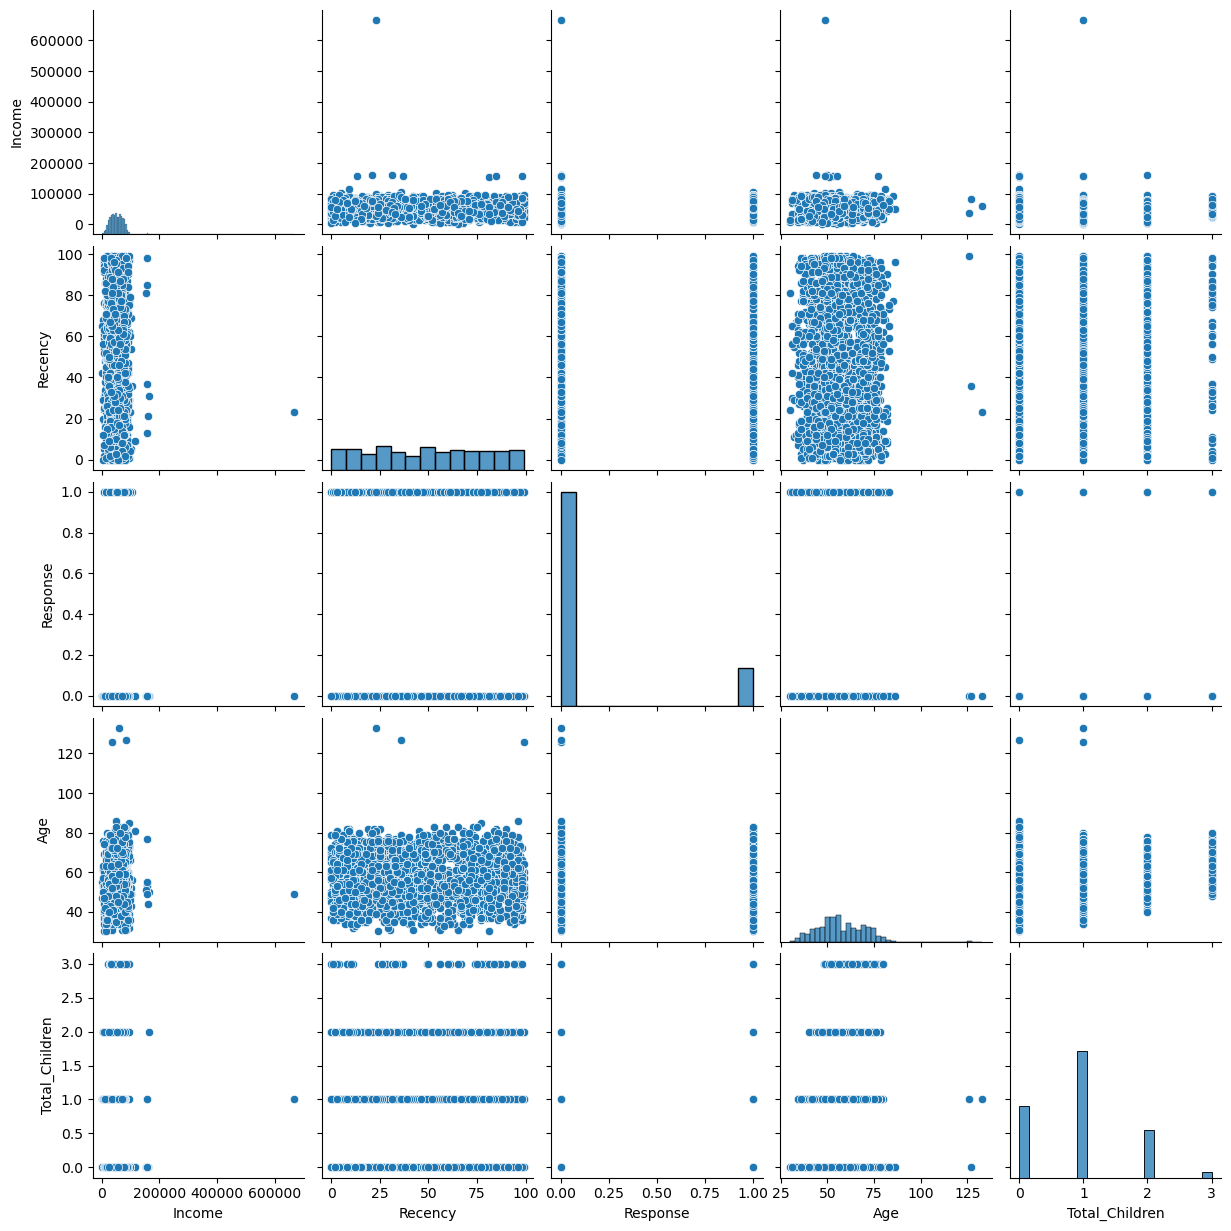

In [25]:
cols = ["Income","Recency","Response","Age","Total_Children"]
#relative plot
sns.pairplot(df_cleaned[cols])

In [26]:
#remove outliers
print("dataset with outliers",len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned = df_cleaned[(df_cleaned["Income"]<600_000)]
print("dataset without outliers",len(df_cleaned))

dataset with outliers 2240
dataset without outliers 2236


In [27]:
corr = df_cleaned.corr(numeric_only = True)

<Axes: >

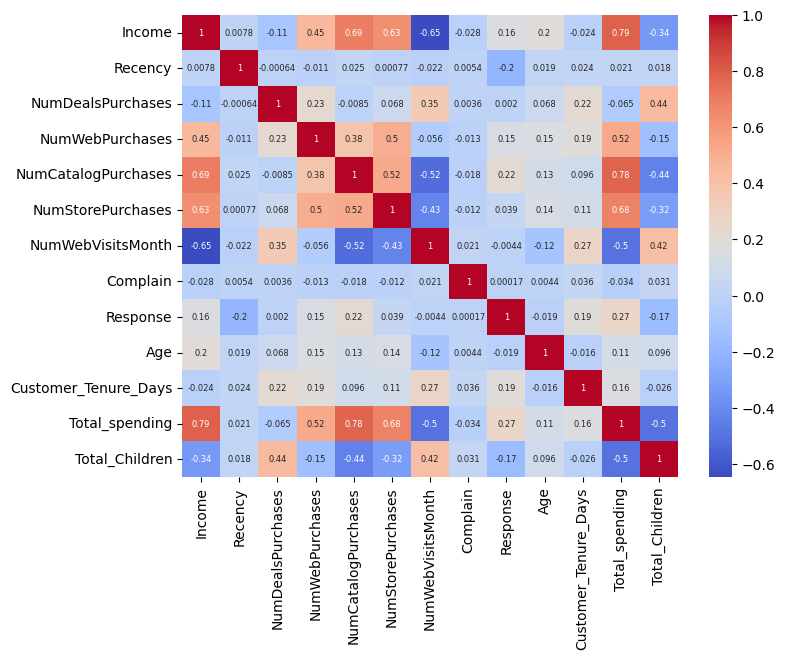

In [28]:
plt.figure(figsize =(8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws = {"size":6},
    cmap = "coolwarm"
)

# ENCODING

In [29]:
from sklearn.preprocessing import OneHotEncoder

In [30]:
ohe = OneHotEncoder()
cat_cols = ["Education","Living_with"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [31]:
enc_df =pd.DataFrame(enc_cols.toarray(),columns= ohe.get_feature_names_out(cat_cols),index = df_cleaned.index)


In [32]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis=1)

In [33]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [34]:
df.shape

(2240, 27)

In [35]:
df_cleaned.shape

(2236, 15)

In [36]:
df_encoded.shape

(2236, 18)

# SCALING

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
X= df_encoded

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [40]:
X

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,59,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,80,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,45,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,70,156,843,1,0.0,1.0,0.0,0.0,1.0


In [41]:
X_scaled.shape

(2236, 18)

In [42]:
from sklearn.decomposition import PCA


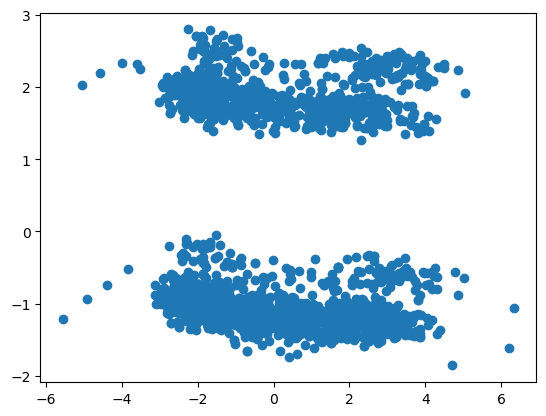

In [43]:
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0],X_pca[:,1])

In [45]:
 pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [47]:
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

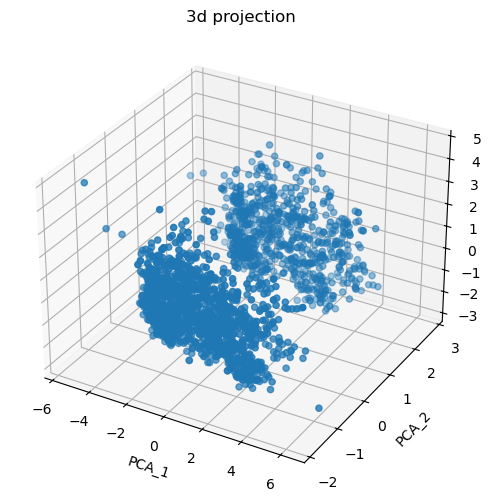

In [48]:
fig = plt.figure(figsize= (8,6))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA_1")
ax.set_ylabel("PCA_2")
ax.set_zlabel("PCA_3")
ax.set_title("3d projection")

# ANALYZE K VALUES 
## 1. Elbow method

In [53]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [57]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters = k,random_state = 42 )
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [58]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [59]:
print("best value of k = ", optimal_k)

best value of k =  4


Text(0, 0.5, 'wcss')

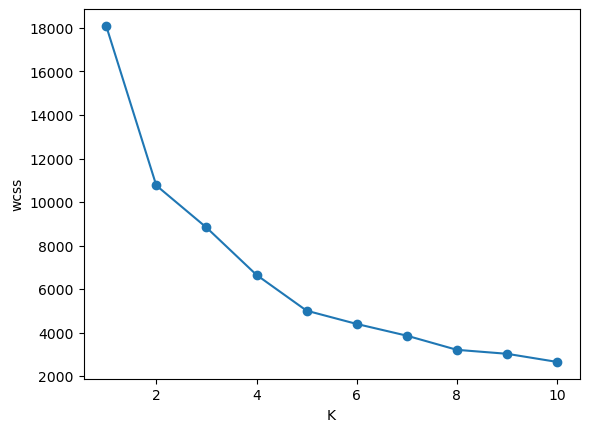

In [60]:
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("wcss")

Text(0, 0.5, 'silhouette_score')

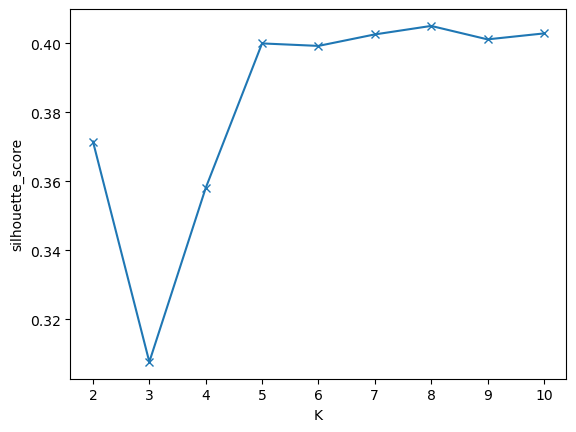

In [62]:
from sklearn.metrics import silhouette_score
scores =[]
for k in range(2,11):
    kmeans = KMeans(n_clusters = k,random_state = 42 )
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

plt.plot(range(2,11),scores,marker="x")
plt.xlabel("K")
plt.ylabel("silhouette_score")
    

Text(0, 0.5, 'SS')

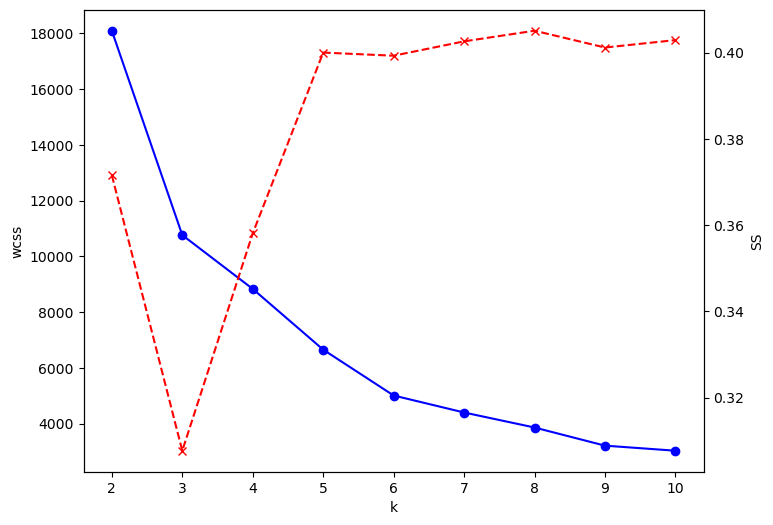

In [63]:
#combined graph
k_range = range(2,11)
fig,ax1  = plt.subplots(figsize = (8,6))
ax1.plot(k_range,wcss [:len(k_range)],marker = "o", color = "blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2= ax1.twinx()
ax2.plot(k_range,scores [:len(k_range)],marker = "x", color = "red",linestyle ="--")
ax2.set_ylabel("SS")

Text(0.5, 0.92, '3d projection')

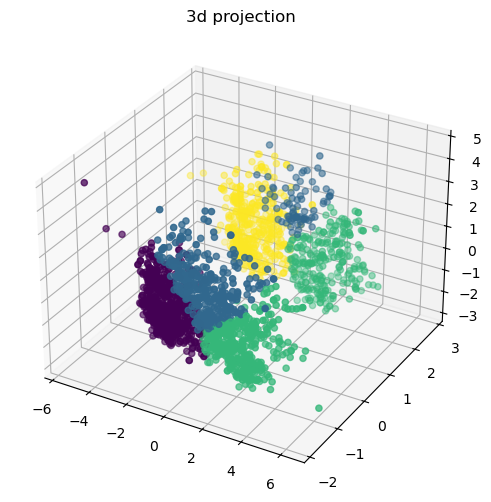

In [65]:
kmeans = KMeans(n_clusters = 4,random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)
fig = plt.figure(figsize= (8,6))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)
ax.set_title("3d projection")

In [66]:
#Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering

Text(0.5, 0.92, '3d projection')

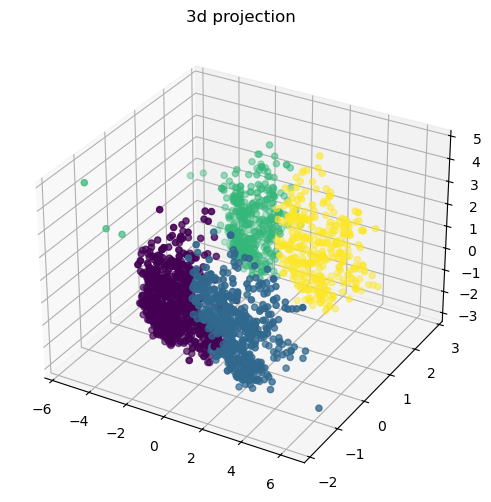

In [67]:
agg_clf = AgglomerativeClustering(n_clusters = 4, linkage = "ward")
label_agg = agg_clf.fit_predict(X_pca)
fig = plt.figure(figsize= (8,6))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=label_agg)
ax.set_title("3d projection")

# Characterization of CLusters

In [73]:
X["clusters"]= label_agg

In [74]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_with_Alone,Living_with_Partner,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='clusters', ylabel='count'>

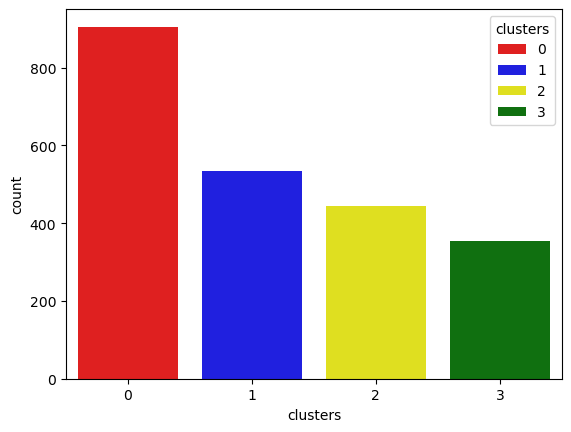

In [75]:
pal = ["red","blue","yellow","green"]
sns.countplot(x=X["clusters"],palette= pal, hue = X["clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

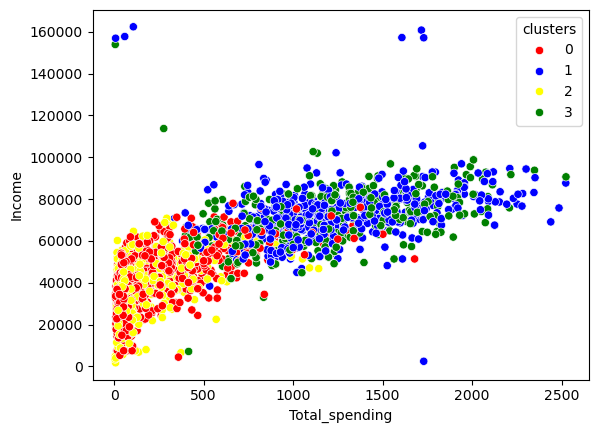

In [76]:
#income vs Spending patterns
sns.scatterplot(x= X["Total_spending"], y =X["Income"], hue = X["clusters"], palette = pal)

# SUMMARY 

In [78]:
#cluster summary
cluster_summary = X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_Days  Total_spending  \
clu